In [1]:
import py4DSTEM
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

# Load Data

In [16]:
PeaksArray = np.load('PeaksArray_SmallRange.npy')

# Columns represent Qx, Qy, I, Rx, Ry, Qr, Qphi
Qx = PeaksArray[:, 0]
Qy = PeaksArray[:, 1]
Rx = PeaksArray[:, 3]
Ry = PeaksArray[:, 4]

In [17]:
# Set same text size
plt.rcParams.update({'font.size': 14})

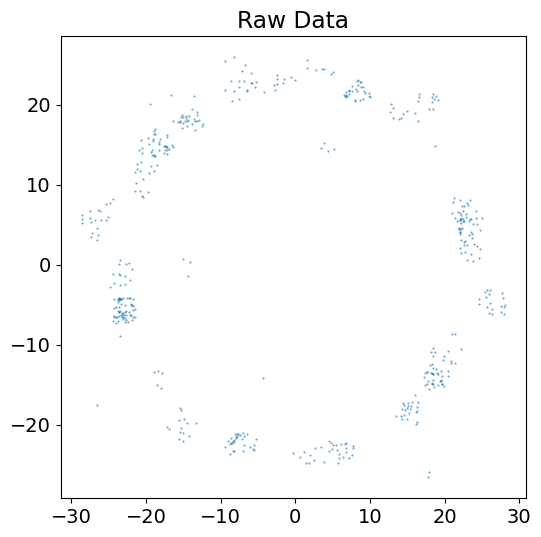

In [18]:
# Plot the data
plt.figure(figsize=[6,6])
plt.title('Raw Data')
plt.scatter(Qx, Qy, s=0.25, alpha=0.7)
plt.show()

# DBSCAN

## Level 1 clustering

In [20]:
# DBScan Parameters
s = 0.4 
eps = 2
db1 = DBSCAN(eps=eps, min_samples=4).fit(PeaksArray[:,[0,1,3,4]]*np.array([1, 1, s, s])) 

In [21]:
# Colour Scheme
colours = []
r = db1.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

### Plots

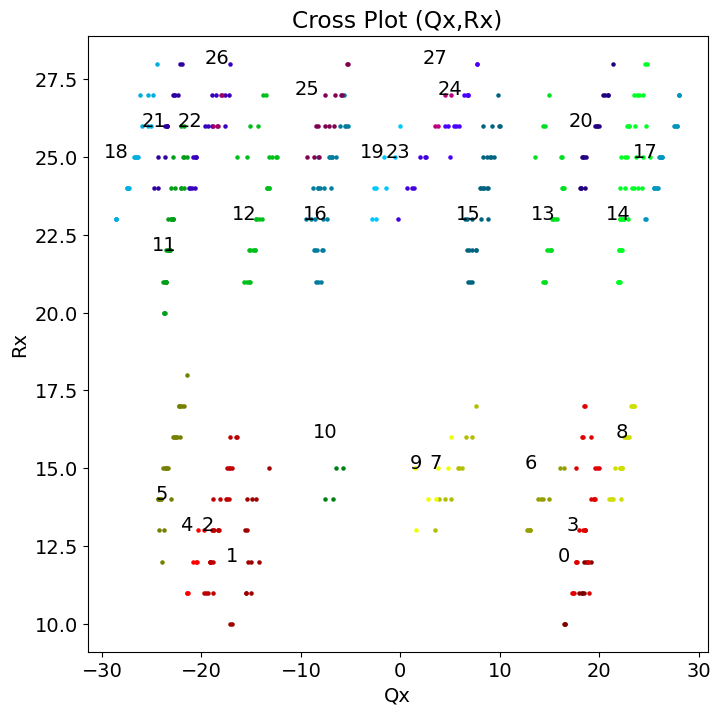

In [22]:
# Cross Plot (Qx,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Rx')
plt.show()

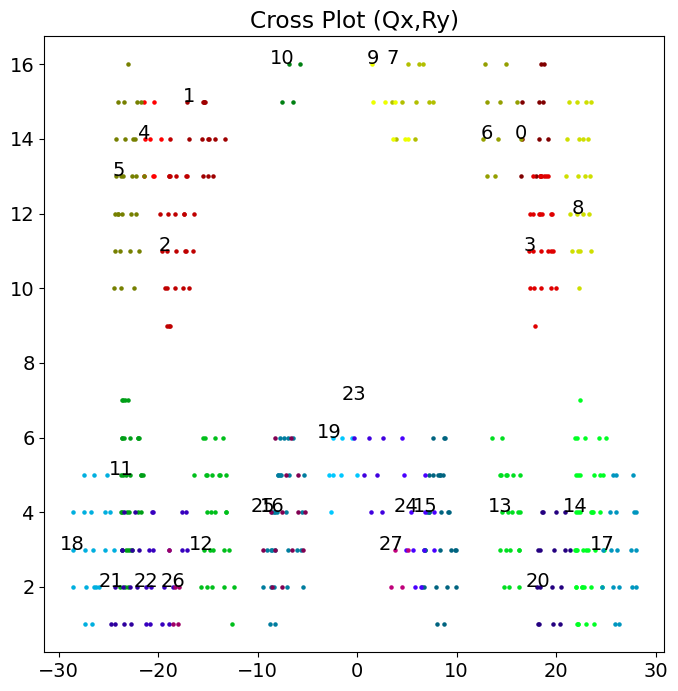

In [24]:
# Cross Plot (Qx,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qx,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

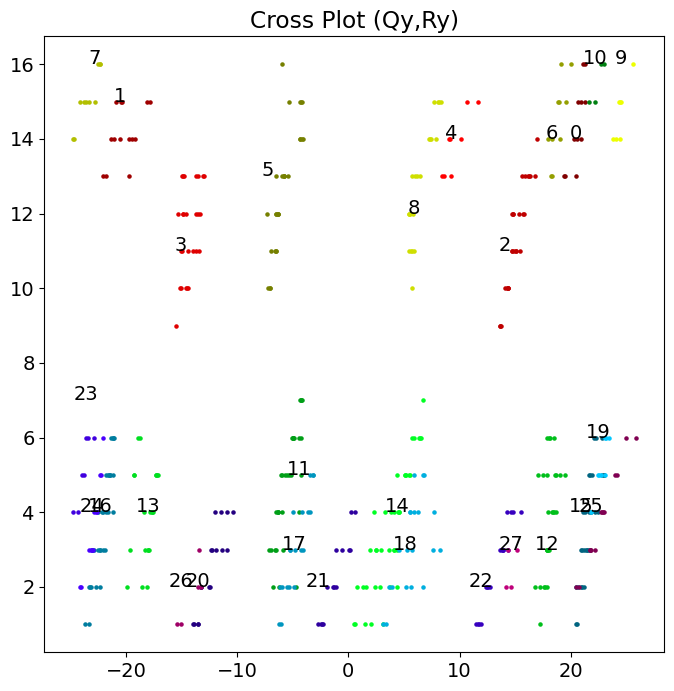

In [25]:
# Cross Plot (Qy,Ry)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Ry)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 4], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 4]+1, 
            int(i),
            horizontalalignment='center'
        )

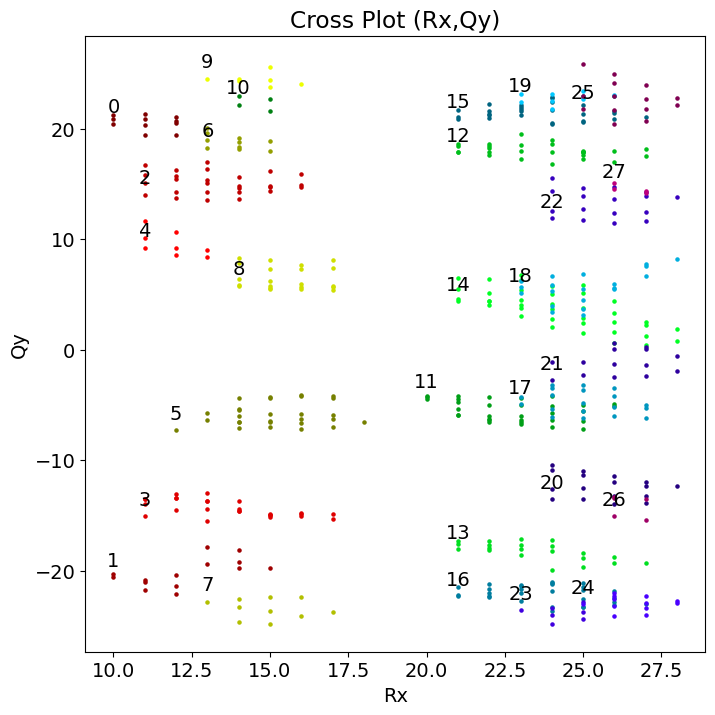

In [26]:
# Cross Plot (Rx,Qy)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Rx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 3], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 3], 
            Cluster[n, 1]+1, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Rx')
plt.ylabel('Qy')
plt.show()

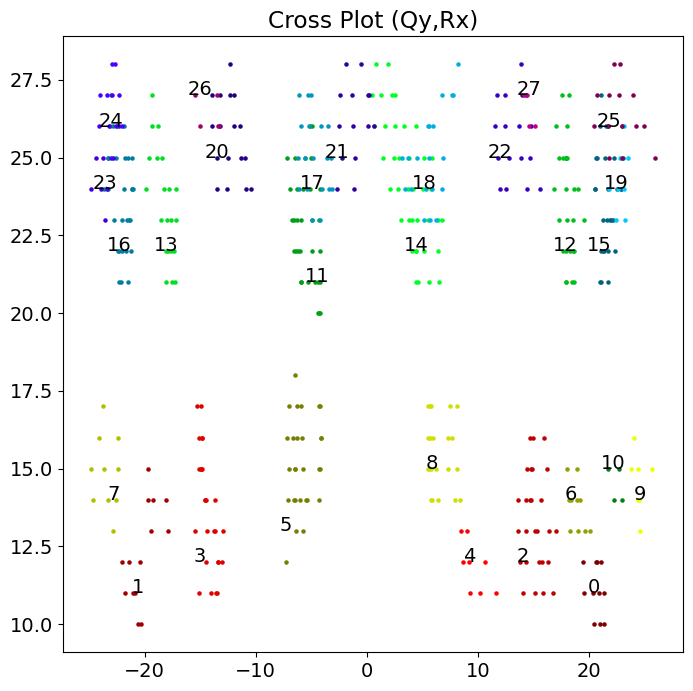

In [27]:
# Cross Plot (Qy,Rx)
plt.figure(figsize=[8,8])
plt.title('Cross Plot (Qy,Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 3]+1, 
            int(i),
            horizontalalignment='center'
        )

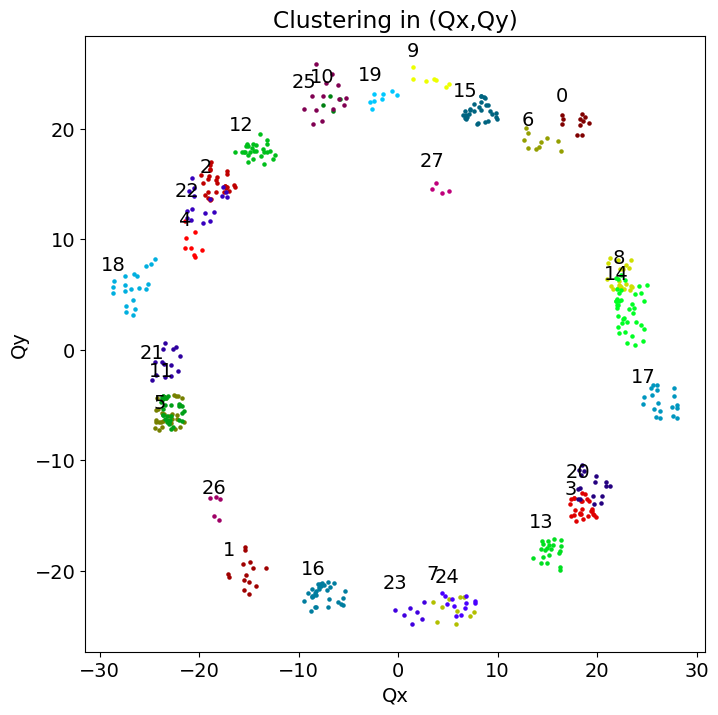

In [28]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 0], Cluster[:, 1], color = colours[i], label = i, s=5, alpha=1)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 0], 
            Cluster[n, 1]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qx')
plt.ylabel('Qy')
plt.show()

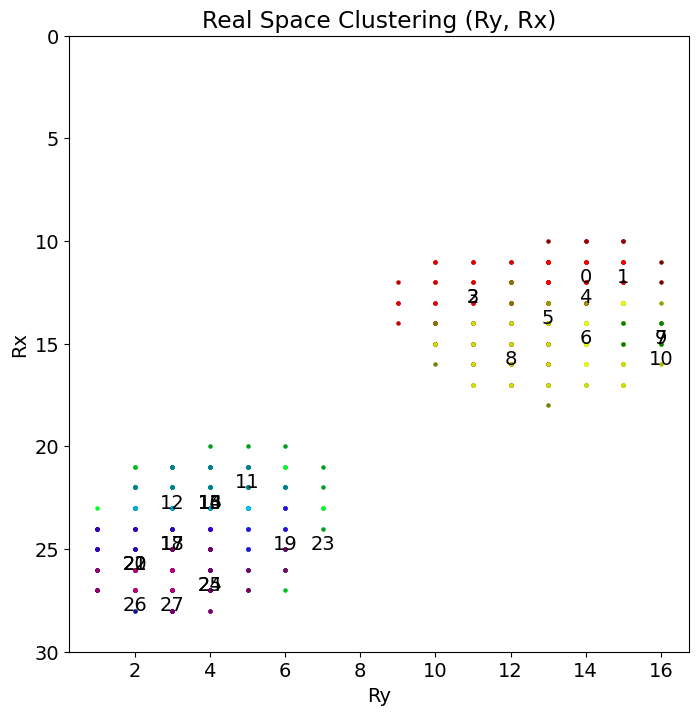

In [29]:
# Real space
plt.figure(figsize=[8,8])
plt.title('Real Space Clustering (Ry, Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 4], Cluster[:, 3], color = colours[i], label = i, s=5, alpha=1)
    
    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 4]+1, 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Ry')
plt.ylabel('Rx')
plt.ylim(30,0)
plt.show()

## Centre of Mass

In [30]:
# find COM for each cluster
def COM_X(m,x):
    '''
    Calculates COM for x-coordinate.

    Data types:
    m: int or numpy array
    x: numpy array
    '''
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    '''
    Calculates COM for y-coordinate.

    Data types:
    m: int or numpy array
    y: numpy array
    '''
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, label, Weight=True):
    '''
    Calculates COM for every cluster in a clustering graph.
    
    Data types:
    Data: numpy array
    Range: numpy array
    label: numpy array
    Weight: bool
        if True, applies pixel weighting to the centre of masses

    '''
    COM_Values = []

    # loop over all clusters
    for p in Range:
        Cluster = Data[np.where(label == p)]

        if Weight:
            # COM weighting
            COM_Values.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        else:
            #COM no weighting
            COM_Values.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Values

In [31]:
COM_Values = Cluster_COM(PeaksArray, np.arange(0, max(db.labels_)+1,1), db.labels_, Weight = True)

In [34]:
COM_Values = np.array(COM_Values)

## Level 2 Clustering (Clustering on COM)

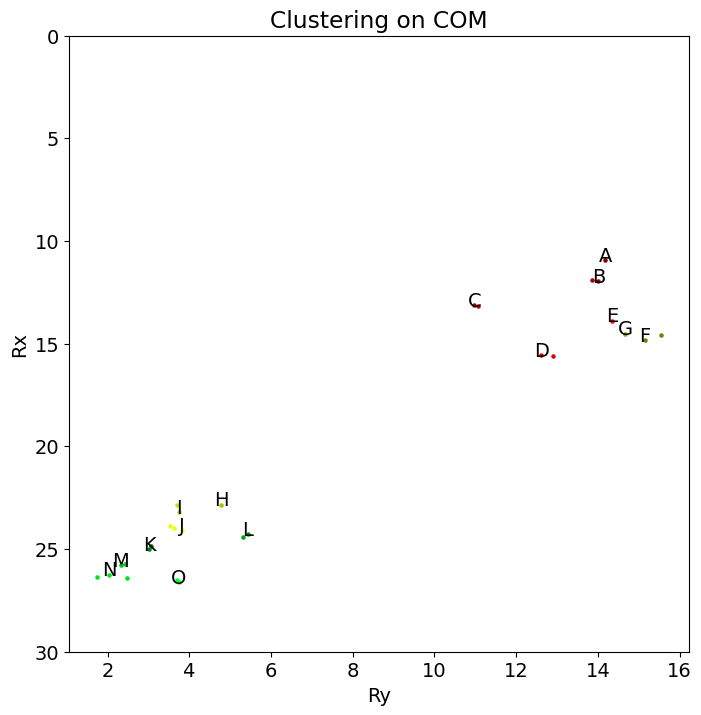

In [35]:
# Second level clustering on COM
db2 = DBSCAN(eps=0.5, min_samples=1).fit(COM_Values)

# Plot
plt.figure(figsize=[8,8])
plt.title('Clustering on COM')

Text = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

for i in range(r):   
    Cluster = COM_Values[np.where(db2.labels_ == i)]
    scatter = plt.scatter(Cluster[:,1], Cluster[:,0], color = colours[i], label = i, s=5, alpha=1)

    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+.05, 
            str(Text[i]),
            horizontalalignment='center'
        )
plt.ylim(30,0)
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.show()

## Virtual Images of Individual Crystals

In [42]:
def VirtualImage(Data, Label, Index, x, y, Rx, Ry):
    '''
    Function which produces the Digital Dark Field Image of a selected cluster

    Data types:
    Data: numpy array
    Label: numpy array
        this corresponds to the clustering type, so for DBSCAN use db.labels_
        
    Index: Int
        select the index of the cluster
    x: Int 
    y: Int 
    Rx: numpy array
    Ry: numpy array
    returns: NoneType
        virtual image of cluster
    '''
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, x]
    Ryc = Cluster[:, y]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Rx.max().astype('int')+1, Ry.max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,1]

    # Plot
    plt.figure(figsize=[7,7])
    plt.xlabel('Ry')
    plt.ylabel('Rx')
    plt.imshow(image)
    plt.show()

# may want to add subplots to this to be able to save image

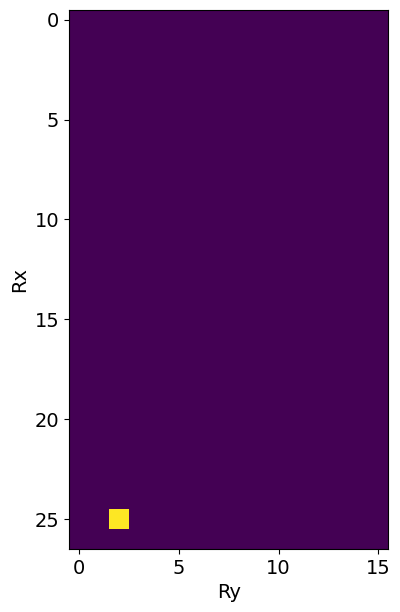

In [43]:
VirtualImage(COM_Values, db2.labels_, 12, 0, 1, COM_Values[:,0], COM_Values[:,1])

## Transfer level 1 and level 2 cluster labels into the data array 

In [70]:
# Identify the unique labels in level 2
L2numlabs = np.unique(db2.labels_)

# Insert alphabetical letters
L2letterlabs = string.ascii_uppercase[:L2numlabs.shape[0]]

# Create dict
labs1 = dict(list(zip(L2numlabs, L2letterlabs))) # numbers to letters
labs2 = dict(list(zip(L2letterlabs, L2numlabs))) # letters to numbers

In [71]:
# Add level 1 labels to data array
Dataset = np.column_stack((PeaksArray, db1.labels_))

In [72]:
# Indexing to ensure correct length of lvl2 labels, also maps lvl1 clusters to lvl2 clusters
indexing = db2.labels_[db1.labels_]

In [73]:
# Source - https://stackoverflow.com/a/57058920
# Posted by yatu
# Retrieved 2026-03-15, License - CC BY-SA 4.0
lvl2 = np.vectorize(labs1.get)(indexing.astype(int))

In [74]:
FullDataset = np.column_stack((Dataset, lvl2))

In [75]:
# New Data Array Columns
Qx = FullDataset[:,0]
Qy = FullDataset[:,1]
I = FullDataset[:,2]
Rx = FullDataset[:,3]
Ry = FullDataset[:,4] 
Qr = FullDataset[:,5]
Qphi = FullDataset[:,6]
Clusters1 = FullDataset[:,7]
Clusters2 = FullDataset[:,8] 

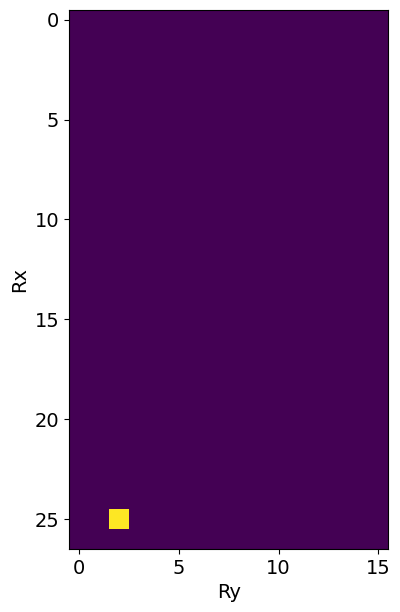

In [76]:
# Try Virtual Images on new dataset for individual crystals using dict
VirtualImage(COM_Values, db2.labels_, labs2['M'], 0, 1, COM_Values[:,0], COM_Values[:,1])

## Cluster on Qx, Qy for individual Crystals

### Crystal 'A'

In [77]:
# Example Select Crystal A (CA)
CA = FullDataset[:, 8] == 'A'

# All diffraction vectors associated with Crystal A
CA_FullDataset = FullDataset[CA]

# Change values into floats
CA_Data = CA_FullDataset[:,0:8].astype(float)

# Extract Qx, Qy from crystal A
Aqx = CA_Data[:,0]
Aqy = CA_Data[:,1]

In [78]:
# DBScan Parameters
#s = 0.4 
#eps = 1
db3 = DBSCAN(eps=0.4, min_samples=1).fit(CA_Data[:,[0, 1, 3, 4]]) 

# Colour Scheme
colours = []
r = db3.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md



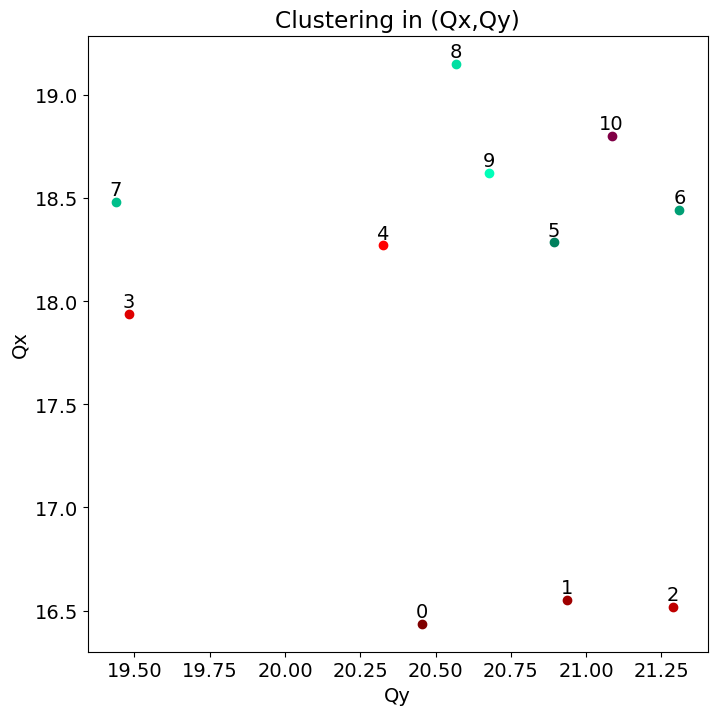

In [79]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = CA_Data[np.where(db3.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 0], color = colours[i], label = i)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+0.03, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qy')
plt.ylabel('Qx')
plt.show()

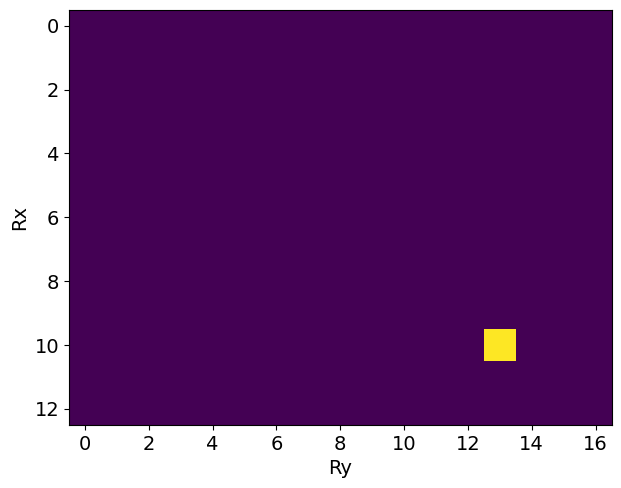

In [80]:
VirtualImage(CA_Data, db3.labels_, 0, 3, 4, CA_Data[:,3], CA_Data[:,4])

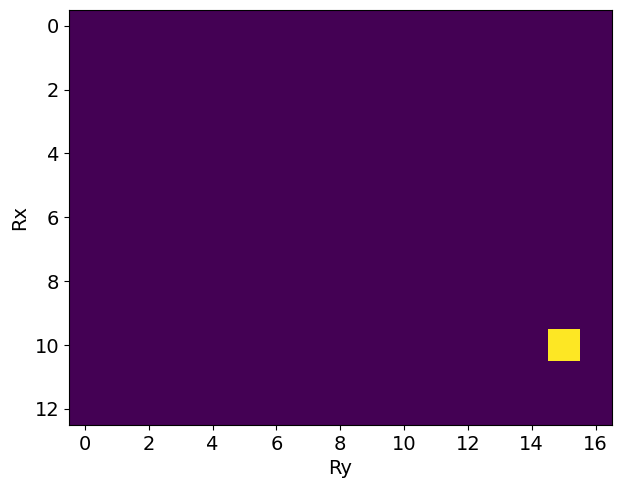

In [81]:
VirtualImage(CA_Data, db3.labels_, 2, 3, 4, CA_Data[:,3], CA_Data[:,4])

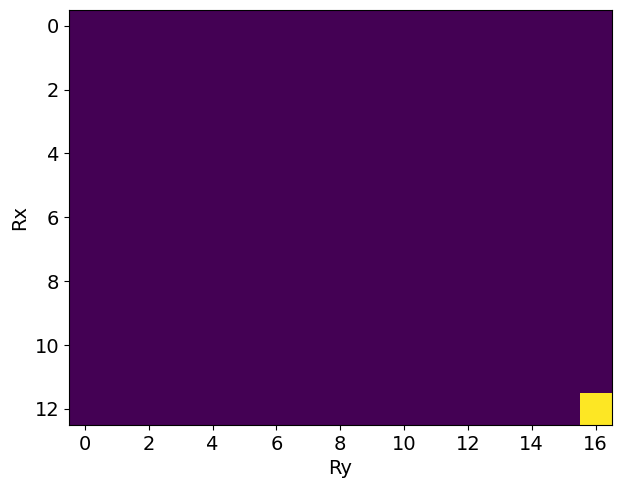

In [82]:
VirtualImage(CA_Data, db3.labels_, 10, 3, 4, CA_Data[:,3], CA_Data[:,4])

In [83]:
# Notes
# The clusters so far appear to be in the same spatial region
# This could suggest they belong to the same crystal

### Crystal 'N'

In [84]:
# Example Select Crystal N (CN)
CN = FullDataset[:, 8] == 'N'

# All diffraction vectors associated with Crystal A
CN_FullDataset = FullDataset[CN]

# Change values into floats
CN_Data = CN_FullDataset[:,0:8].astype(float)

# Extract Qx, Qy from crystal N
Nqx = CN_Data[:,0]
Nqy = CN_Data[:,1]

In [85]:
# DBScan Parameters
#s = 0.4 
#eps = 1
db3 = DBSCAN(eps=1.5, min_samples=1).fit(CN_Data[:,[0, 1, 3, 4]]) 

# Colour Scheme
colours = []
r = db3.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

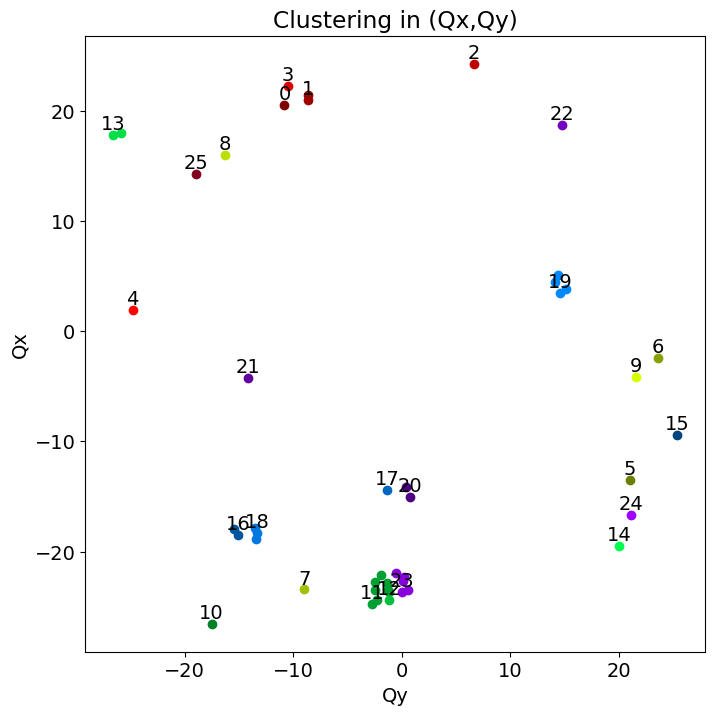

In [86]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = CN_Data[np.where(db3.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 0], color = colours[i], label = i)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+0.5, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qy')
plt.ylabel('Qx')
plt.show()

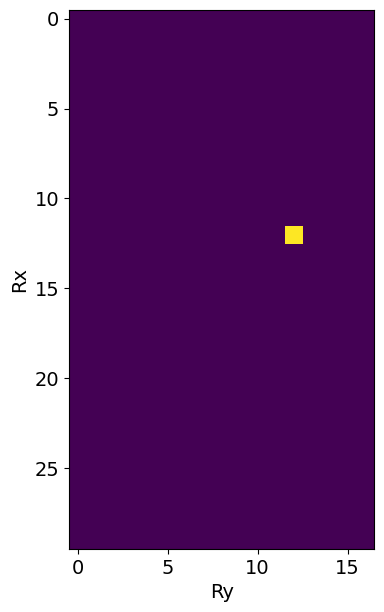

In [87]:
VirtualImage(CN_Data, db3.labels_, 2, 3, 4, CN_Data[:,3], CN_Data[:,4])

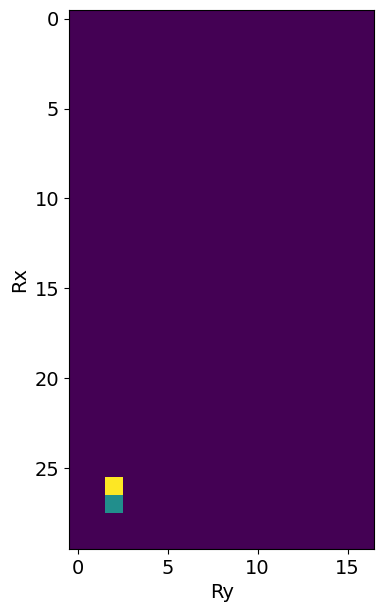

In [88]:
VirtualImage(CN_Data, db3.labels_, 20, 3, 4, CN_Data[:,3], CN_Data[:,4])

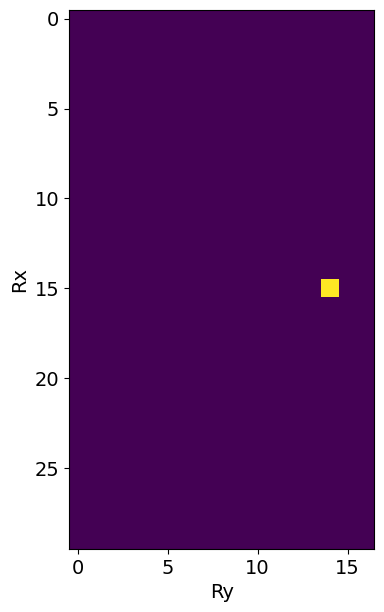

In [89]:
VirtualImage(CN_Data, db3.labels_, 6, 3, 4, CN_Data[:,3], CN_Data[:,4])

In [90]:
# Notes
# Notice that all the clusters dont appear to be in the same region
# Some of these clusters may correspond to noise from DBSCAN

need to fix digital dark field function on github?